In [1]:
# https://sites.research.google/gr/open-buildings/#open-buildings-download

# import importlib
# importlib.reload(your_module)
%load_ext autoreload
# Reload all modules before execution
%autoreload 2  


# BUILD DUCKDB FROM PARQUET (PAGE FAULT) 

In [7]:
import json
import importlib
import duckdb
import cisei_lib.geo_datasets.gob_footprints_utils as fp
importlib.reload(fp)
# fp.update_height(None, "openbuilding-curitiba") => DANGER (OUTDATED)

tx = (-25.4297, -49.2719)
rx = (-25.4411, -49.2800)

index_file = 'dem-datasets/bldg/gob-h-parana-parquets/index-geo.json'
res = fp.identify_required_tiles([tx,rx], index_file)

con = duckdb.connect(database=':memory:')
fp.duckdb_page_fault(con, res, 'dem-datasets/bldg/gob-h-parana-parquets')
# print( fp.check_db_bounds(con) )
# print( fp.check_db_schema(con) )
# print(fp.check_top_buildings(con, 10, 10))
# con.close()




Page Fault: Loading OpenBuildings_S26_W50.parquet into memory...


## Test Fresnel Features extraction

Registering UDF...
Plot saved with 84 real polygons.


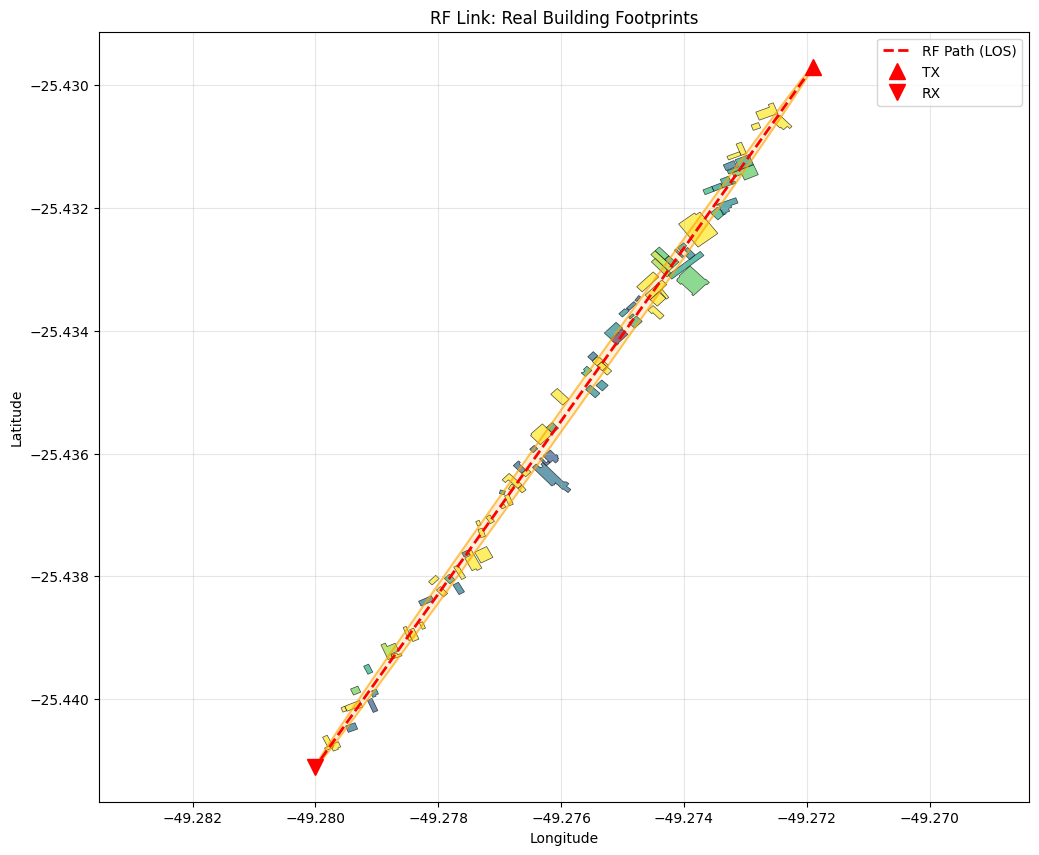

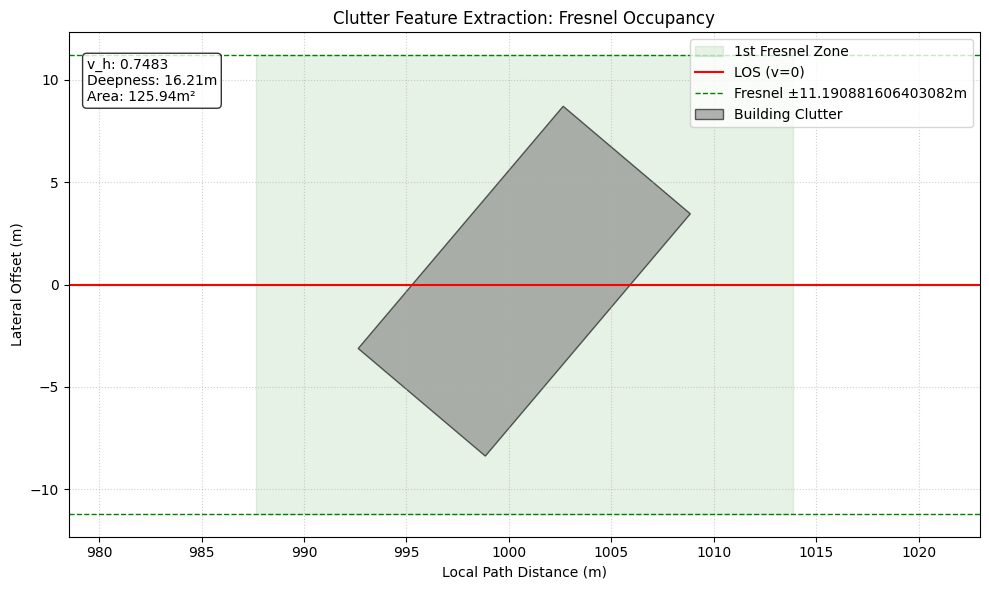

126.1917


In [8]:
importlib.reload(fp)
blds, cols =  fp.get_link_obstacles(con, tx, rx, 10, None)
lat, lon = blds[0][cols['latitude']], blds[0][cols['longitude']]
# fp.plot_rf_with_polygons(tx, rx, blds, cols)
# print( fp.is_building_intersecting(lat, lon, *tx, *rx, 50))
res = fp.get_max_fresnel_radius(tx, rx)
blds, cols = fp.get_precise_fresnel_buildings(con, tx, rx, res[0])
fp.plot_rf_with_polygons(tx, rx, blds, cols)
bid = 4
bld, area_in_meters =  blds[bid][cols['geometry']], blds[bid][cols['area_in_meters']]
vertices, link_m = fp.project_wkt_to_line(*tx, *rx, bld)
ff = fp.extract_fresnel_features(vertices, link_m, res[0])
fp.show_building_clutter(vertices, res[0], ff)
print(area_in_meters)
# con.close()


# INSPECT info-geo.json (GeoTiff)

In [23]:
import importlib
import cisei_lib.geo_datasets.dem_utils as du
importlib.reload(du)
tiff = 'tile_zzWLjBfU9wY.tif'
index = '/media/einstein-bohr/ANIMA/Datasets/G-Heights/index-geo.json'
print(du.find_tile_by_name(index, tiff))

({'id_filename': 'tile_zzWLjBfU9wY.tif', 'crs_native': 'EPSG:32722', 'px_width': 25000, 'px_height': 25000, 'geo_west': -48.505582933886664, 'geo_south': -22.874129242172536, 'geo_east': -48.38178851679397, 'geo_north': -22.7593684924456, 'affine_vector': [0.5, 0.0, 756136.0, 0.0, -0.5, 7480744.0], 'band_count': 3, 'b1_dtype': 'float32', 'b1_nodata': -99.0, 'b1_interp': 'gray', 'b1_desc': 'building_fractional_count', 'b2_dtype': 'float32', 'b2_nodata': -99.0, 'b2_interp': 'undefined', 'b2_desc': 'building_height', 'b3_dtype': 'float32', 'b3_nodata': -99.0, 'b3_interp': 'undefined', 'b3_desc': 'building_presence', 'coord_type': 'projected', 'res_m_x': 0.5, 'res_m_y': 0.5, 'utm_left': 756136.0, 'utm_right': 768636.0, 'utm_bottom': 7468244.0, 'utm_top': 7480744.0, 'area_km2': 161.5131}, {'w': -48.505582933886664, 'e': -48.38178851679397, 's': -22.874129242172536, 'n': -22.7593684924456})


# SPLIT DUCKDB INTO PARQUETS AND CREATE AN INDEX

In [23]:
import importlib
import cisei_lib.geo_datasets.gob_footprints_utils as fp
importlib.reload(fp)
db_file = "parana_buildings.db"
output_dir = "gob-h-parana-parquets"
# fp.shatter_duckdb_footprints(db_file, output_dir)
# vm.initialize_building_lake(con, PARQUET_2D, PARQUET_H)
# fp.shatter_duckdb_with_heights(con,output_dir) 
#fp.create_parquet_index(output_dir, f'{output_dir}/index-geo.json')

Indexing 39 parquelets...
Building index complete. File saved to gob-h-parana-parquets/index-geo.json


# Verify Heights UPDATE (Join Parquets)

In [12]:
from pathlib import Path
import importlib
import verify_marathon as vm
importlib.reload(vm)

import duckdb
con = duckdb.connect(database=':memory:')

#dataset_dir = '/media/einstein-bohr/ANIMA/Datasets'
#GEOTIF_H = f'{dataset_dir}/G-Heights'
PARQUET_2D = 'gob_parana_parquets'
PARQUET_H = 'gob_parana_parquets_temp'
GEOTIF_H = 'openbuilding-curitiba'
vm.initialize_building_lake(con, PARQUET_2D, PARQUET_H)
# 
# schema = con.execute("PRAGMA table_info('buildings')").fetchall()
# print(schema)
#file = f"{dataset_dir}/G-Heights-metadata/processed.txt"
file = 'processed-curitiba.txt'
res = vm.get_processed_inventory(file, GEOTIF_H)

tiffs = list(res.keys())
tiff_path = tiffs[2]
box = res[tiff_path]

#buildings = vm.get_candidates_for_tile(con, box, limit=10)



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Table 'buildings' initialized. Log of empty tiles saved to empty_tiles.log.
Inventory complete: 129 tiles indexed.


## Search parquet database for inspection

In [17]:
coords = -25.432840733036908, -49.27619017632341
url = f"https://www.google.com/maps?q={coords[0]:.7f},{coords[1]:.7f}&t=k"
sample_df = vm.inspect_area_results(con, *coords, delta = 0.001) 
print(url)
print(sample_df)


https://www.google.com/maps?q=-25.4328407,-49.2761902&t=k
       rowid  area_in_meters  confidence full_plus_code   latitude  longitude  \
0    7172442         84.5717      0.8628  586GHP9F+4884 -25.432222 -49.276666   
1   11447111        292.0589      0.7759  586GHP9F+57RQ -25.432009 -49.276847   
2    3230595        373.6926      0.8215  586GHP8F+G95R -25.433729 -49.276525   
3    3608969        278.3976      0.8471  586GHP8F+PVXH -25.433137 -49.275258   
4    3684619        122.8982      0.8114  586GHP8F+HR3M -25.433605 -49.275459   
5    3722250         37.8107      0.7328  586GHP8F+FJVP -25.433758 -49.275947   
6    9063572        432.5153      0.8441  586GHP9F+4FMF -25.432164 -49.276328   
7    1839943        404.5745      0.9367  586GHP9F+3633 -25.432372 -49.276959   
8    2070171       1514.3429      0.8502  586GHP8F+W62H -25.432736 -49.276974   
9    2201422         55.5852      0.7564  586GHP8F+HV2G -25.433611 -49.275359   
10   2317216        207.9705      0.8795  586GHP8F+

## Create a report

In [11]:
importlib.reload(vm)
report = vm.run_marathon_audit(con, res)
report_file = 'report_curitiba.parquet'
vm.save_report(report,report_file) 
#temp = f"{dataset_dir}/G-Heights-metadata/{report_file}"
#report =  vm.load_report(temp)
#report.head(10)
report.sort_values('discovery_rate', ascending=False).head(10)
vm.report_summary(report)
# con.close()

TIFF Name                      | Total | Found | Rate %  | MAE (m) 
----------------------------------------------------------------------
Processed: 0
tile_Nyk7pUTx3YY.tif           | 50    | 42    | 84.0    | 0.208   
Processed: 100
tile_yHcs2COLZKs.tif           | 50    | 48    | 96.0    | 0.219   
Success: Report saved to report_curitiba.parquet
--- GLOBAL PRODUCTION YIELD ---
Total Buildings Attempted: 6,095
Total Buildings Validated: 5,064
Overall Success Rate:      83.08%
